# Simple Quantum Circuits with Toy Datasets: Training
## 120 Training (Balanced) | Batch Size 8 | 30 Epochs | LR 0.01 | Seed 42 | Target (y) = 3 Classes | Data Reupload = 4

## Setup

PennyLane is now imported as `qp` instead of `qml`.

Source: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml

In [1]:
import pennylane as qp
from pennylane import numpy as np

import matplotlib.pyplot as plt

## Load Dataset: Iris

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
(X.shape, y.shape)

((150, 4), (150,))

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((120, 4), (30, 4), (120,), (30,))

## Data Preprocessing

Features are standardized with `StandardScaler()` so each one maps to rotation angles on a comparable scale, rather than larger-magnitude features dominating the encoded state.

In [8]:
X_test

array([[4.4, 3. , 1.3, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [4.9, 2.4, 3.3, 1. ],
       [5. , 2.3, 3.3, 1. ],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 3.3, 4.7, 1.6],
       [4.6, 3.6, 1. , 0.2],
       [5.4, 3.4, 1.7, 0.2],
       [6.5, 3. , 5.2, 2. ],
       [5.4, 3. , 4.5, 1.5],
       [7.3, 2.9, 6.3, 1.8],
       [6.9, 3.1, 5.1, 2.3],
       [6.5, 3. , 5.8, 2.2],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.4, 1.5, 0.2],
       [5. , 3.3, 1.4, 0.2],
       [5.8, 4. , 1.2, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [6.1, 2.9, 4.7, 1.4],
       [6. , 3. , 4.8, 1.8],
       [5.4, 3.7, 1.5, 0.2],
       [6.7, 3.1, 5.6, 2.4],
       [6.6, 2.9, 4.6, 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 2.8, 5.6, 2.2],
       [6.7, 3. , 5. , 1.7],
       [6.6, 3. , 4.4, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6.5, 3. , 5.5, 1.8],
       [5.2, 3.4, 1.4, 0.2]])

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_test

array([[4.4, 3. , 1.3, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [4.9, 2.4, 3.3, 1. ],
       [5. , 2.3, 3.3, 1. ],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 3.3, 4.7, 1.6],
       [4.6, 3.6, 1. , 0.2],
       [5.4, 3.4, 1.7, 0.2],
       [6.5, 3. , 5.2, 2. ],
       [5.4, 3. , 4.5, 1.5],
       [7.3, 2.9, 6.3, 1.8],
       [6.9, 3.1, 5.1, 2.3],
       [6.5, 3. , 5.8, 2.2],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.4, 1.5, 0.2],
       [5. , 3.3, 1.4, 0.2],
       [5.8, 4. , 1.2, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [6.1, 2.9, 4.7, 1.4],
       [6. , 3. , 4.8, 1.8],
       [5.4, 3.7, 1.5, 0.2],
       [6.7, 3.1, 5.6, 2.4],
       [6.6, 2.9, 4.6, 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 2.8, 5.6, 2.2],
       [6.7, 3. , 5. , 1.7],
       [6.6, 3. , 4.4, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6.5, 3. , 5.5, 1.8],
       [5.2, 3.4, 1.4, 0.2]])

## Angle Encoding with Data Reuploading

Using the illustrations in the PennyLane tutorial for the purpose of learning, we have:

<img src="img/universal_dnn.png" width="30%">

- Top diagram, quantum side:
    - 1 wire = 1 qubit.
    - 2 squares = 2 gates.
    - 3 blocks (A, B, C) = data re-uploaded 3 times on 1 qubit.
    - 2 gates per block x 3 blocks = 6 gates on 1 qubit.
- Bottom diagram, quantum side:
    - 2 wires = 2 qubits.
    - 2 squares = 2 gates.
    - 2 blocks (A, B) = data reuploaded 2 times on each qubit.
    - 2 gates per block x 2 blocks = 4 gates on each qubit.
    - Entanglement between 2 blocks.

Source: https://pennylane.ai/demos/tutorial_data_reuploading_classifier

In [12]:
# initialize device
num_qubits = 4 # 4 features = 4 qubits
dev = qp.device("default.qubit", wires=num_qubits)

In [13]:
# reupload same classical data 4 times
num_layers = 4

`qp.StronglyEntanglingLayers()` can create entanglements between all available qubits.

Source: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html

In [14]:
# initialize trainable weights
shape = qp.StronglyEntanglingLayers.shape(n_layers=num_layers, n_wires=num_qubits)
rng = np.random.default_rng(12345)
weights = np.array(0.1 * rng.random(size=shape), requires_grad=True)

In [15]:
# weights before training
weights

tensor([[[0.0227336 , 0.03167583, 0.07973655],
         [0.06762547, 0.03911096, 0.03328139],
         [0.05983088, 0.01867342, 0.0672756 ],
         [0.09418029, 0.02482457, 0.09488812]],

        [[0.06672375, 0.00958979, 0.04418397],
         [0.08864799, 0.06974535, 0.03264729],
         [0.07339282, 0.0220135 , 0.00815946],
         [0.01598956, 0.03401002, 0.04651932]],

        [[0.0266421 , 0.08157764, 0.01932944],
         [0.01294691, 0.00916648, 0.0598568 ],
         [0.08547419, 0.06016212, 0.09319884],
         [0.07247814, 0.08605513, 0.09293378]],

        [[0.0546186 , 0.0937673 , 0.04949879],
         [0.02737732, 0.04517787, 0.06650389],
         [0.03308909, 0.0903454 , 0.02570742],
         [0.03398283, 0.02588534, 0.03554465]]], requires_grad=True)

In [16]:
@qp.qnode(dev)
def circuit(x, weights):
    for l in range(num_layers):                                                  # reupload num_layers times
        qp.AngleEmbedding(x, wires=range(num_qubits), rotation="Y")              # 1. encode data with data reuploading
        qp.StronglyEntanglingLayers(weights[l : l + 1], wires=range(num_qubits)) # 2. trainable quantum layer + entanglement

    return [qp.expval(qp.PauliZ(j)) for j in range(num_qubits)]                  # 3. readout for Iris 3-class classification

## Class Distributions

In [17]:
(y_train.shape, y_test.shape)

((120,), (30,))

In [18]:
class_names = iris.target_names
class_numeric_labels = list(i for i in range(len(class_names)))

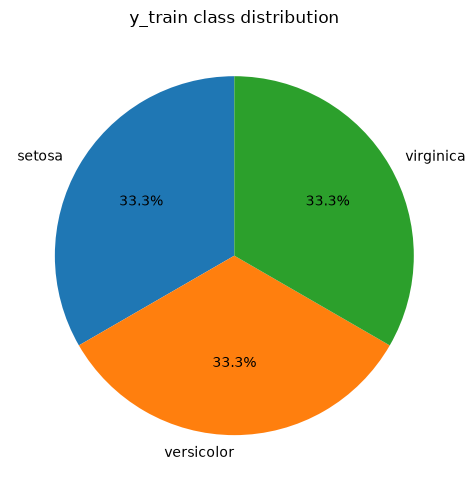

In [19]:
# class counts
classes, counts = np.unique(y_train, return_counts=True)

# pie chart
plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=[class_names[c] for c in classes],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("y_train class distribution")
plt.tight_layout()
plt.show()

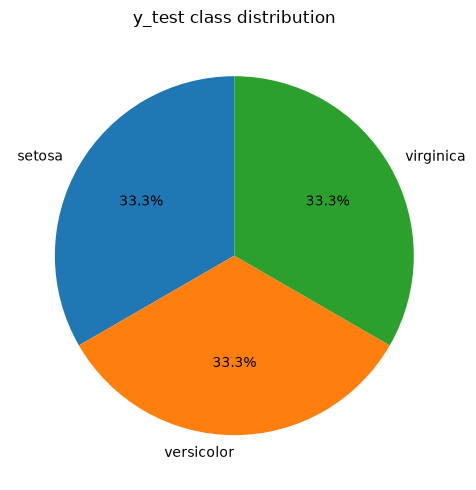

In [20]:
# class counts
classes, counts = np.unique(y_test, return_counts=True)

# pie chart
plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=[class_names[c] for c in classes],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("y_test class distribution")
plt.tight_layout()
plt.show()

## Helper Functions

In [21]:
def softmax(x):
    x = np.array(x)
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

In [22]:
def cost(weights, X_batch, y_batch):
    loss = 0.0
    for x, y in zip(X_batch, y_batch):
        probs = softmax(circuit(x, weights)[:3]) # for 3 classes classification, take 3 exp val out of 4 returned exp val
        loss -= np.log(probs[int(y)] + 1e-10)
    return loss / len(X_batch)

In [23]:
def predict(weights, x):
    preds = circuit(x, weights)[:3]
    return int(np.argmax(softmax(preds)))

In [24]:
def accuracy(weights, X, y):
    correct = sum(predict(weights, x) == label for x, label in zip(X, y))
    return correct / len(y)

## Model Training

In [25]:
opt = qp.AdamOptimizer(stepsize=0.01)
batch_size = 8
epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

In [26]:
for epoch in range(epochs):
    perm = np.random.permutation(len(X_train_scaled)) # shuffle per epoch
    X_shuf = X_train_scaled[perm]
    y_shuf = y_train[perm]

    epoch_loss = 0.0
    num_batches = 0

    for start in range(0, len(X_shuf), batch_size):
        X_batch = X_shuf[start : start + batch_size]
        y_batch = y_shuf[start : start + batch_size]

        (weights, _, _), batch_loss = opt.step_and_cost(cost, weights, X_batch, y_batch)
        epoch_loss += batch_loss
        num_batches += 1

    # train_loss = epoch_loss / num_batches # keras-style: mean of per-batch losses this epoch
    train_loss = cost(weights, X_train_scaled, y_train) # # full-train loss # compare to val_loss for overfitting cases
    val_loss = cost(weights, X_test_scaled, y_test)
    train_acc = accuracy(weights, X_train_scaled, y_train)
    val_acc = accuracy(weights, X_test_scaled, y_test)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"loss: {train_loss:.4f} | "
        f"accuracy: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} | "
        f"val_accuracy: {val_acc:.4f}"
    )

Epoch 1/30 | loss: 1.0123 | accuracy: 0.5417 | val_loss: 0.9761 | val_accuracy: 0.6667
Epoch 2/30 | loss: 0.9512 | accuracy: 0.6417 | val_loss: 0.9180 | val_accuracy: 0.7333
Epoch 3/30 | loss: 0.9144 | accuracy: 0.7083 | val_loss: 0.8875 | val_accuracy: 0.8000
Epoch 4/30 | loss: 0.8817 | accuracy: 0.7583 | val_loss: 0.8619 | val_accuracy: 0.8000
Epoch 5/30 | loss: 0.8497 | accuracy: 0.8000 | val_loss: 0.8326 | val_accuracy: 0.8000
Epoch 6/30 | loss: 0.8174 | accuracy: 0.7833 | val_loss: 0.8100 | val_accuracy: 0.7667
Epoch 7/30 | loss: 0.7912 | accuracy: 0.8083 | val_loss: 0.7968 | val_accuracy: 0.8333
Epoch 8/30 | loss: 0.7723 | accuracy: 0.8000 | val_loss: 0.7856 | val_accuracy: 0.8333
Epoch 9/30 | loss: 0.7597 | accuracy: 0.8000 | val_loss: 0.7771 | val_accuracy: 0.8667
Epoch 10/30 | loss: 0.7494 | accuracy: 0.8083 | val_loss: 0.7687 | val_accuracy: 0.8667
Epoch 11/30 | loss: 0.7398 | accuracy: 0.8333 | val_loss: 0.7595 | val_accuracy: 0.8333
Epoch 12/30 | loss: 0.7303 | accuracy: 0.

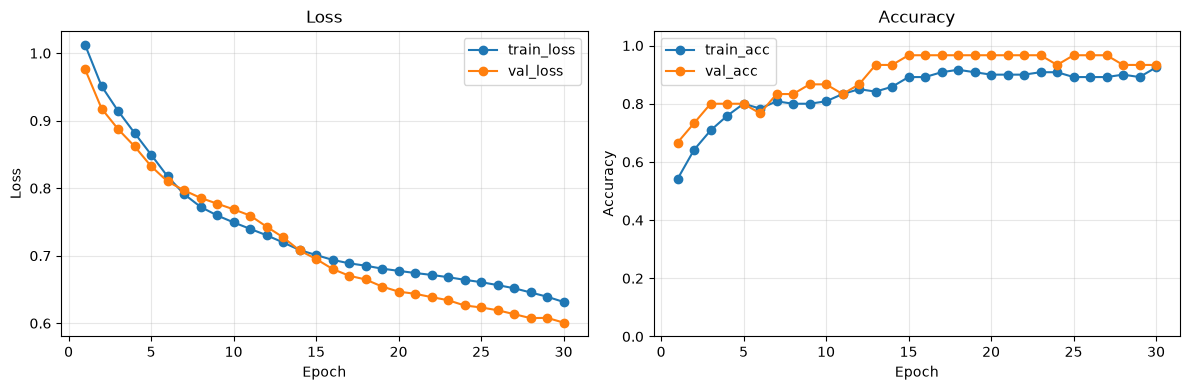

In [27]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train_loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy
axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train_acc")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val_acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation

In [28]:
# weights after training
weights

tensor([[[ 0.62644374, -0.74768569, -0.16817319],
         [-0.21487016, -0.79545248,  0.49264329],
         [-0.13897506, -0.03959996, -0.51226809],
         [ 0.68506024,  0.60417615,  0.64792533]],

        [[ 0.51085391, -0.86909135,  1.12844261],
         [ 0.08684239, -0.03029041,  0.02446298],
         [ 0.23724992, -0.37280331, -0.09006327],
         [ 0.09684201, -0.24720969,  0.12691691]],

        [[ 0.31477511, -0.67941747, -0.66358738],
         [-0.03271546, -1.95789951, -0.05574333],
         [ 0.62215895, -0.66095914,  0.16798795],
         [ 0.76640105, -0.02246948,  0.61505244]],

        [[-0.55798685, -0.67794171,  0.04949879],
         [-1.59820328,  0.47501724,  0.06650389],
         [ 0.09682081,  0.19676241,  0.02570742],
         [-0.16768649, -0.0491008 ,  0.03554465]]], requires_grad=True)

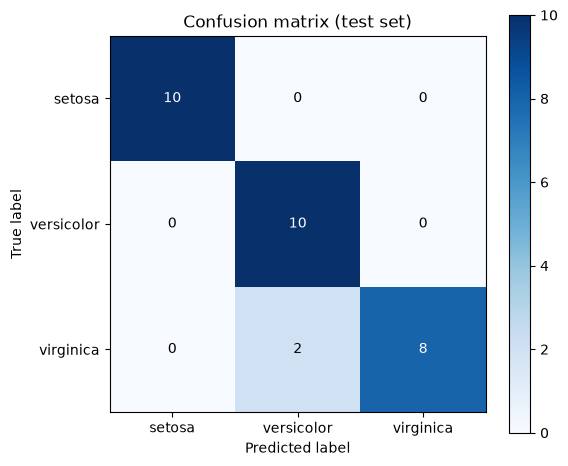

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [29]:
from sklearn.metrics import confusion_matrix, classification_report

# predictions on test set
y_pred = np.array([predict(weights, x) for x in X_test_scaled])

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel="True label",
    xlabel="Predicted label",
    title="Confusion matrix (test set)",
)

# write counts in each cell
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, labels=class_numeric_labels, target_names=class_names))

In [30]:
y_pred

tensor([0, 1, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
        1, 2, 2, 1, 1, 0, 2, 0], requires_grad=True)

In [31]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

## References

- Importing PennyLane as qp: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml
- Encoding data in angles: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- Data reuploading: https://pennylane.ai/demos/tutorial_data_reuploading_classifier
- Strong entangling layers: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html